### Feature Engineering 

In [1]:
import pandas as pd
from datetime import date
import holidays

In [2]:
df = pd.read_csv("/Users/saif/Desktop/ML_Load_Forecasting/data/Silver/df_clean.csv", index_col=0, parse_dates= True)

In [3]:
df.head()

,Load_MW,temperature_2m,wind_speed_10m,shortwave_radiation
2020-01-01 00:00:00,43471.87,1.5,11.4,0.0
2020-01-01 01:00:00,42401.86,2.0,10.3,0.0
2020-01-01 02:00:00,41126.54,1.8,11.2,0.0
2020-01-01 03:00:00,40793.28,1.1,10.1,0.0
2020-01-01 04:00:00,40710.44,0.3,9.4,0.0


### Time features

In [4]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.dayofweek >= 5).astype(int)


In [5]:
de_holidays = holidays.Germany(years = (2020, 2024))

df["is_holiday"] = df.index.normalize().isin(de_holidays).astype(int)

print(df.head())
print(df.describe())

                      Load_MW  temperature_2m  wind_speed_10m  \
2020-01-01 00:00:00  43471.87             1.5            11.4   
2020-01-01 01:00:00  42401.86             2.0            10.3   
2020-01-01 02:00:00  41126.54             1.8            11.2   
2020-01-01 03:00:00  40793.28             1.1            10.1   
2020-01-01 04:00:00  40710.44             0.3             9.4   

                     shortwave_radiation  hour  dayofweek  month  is_weekend  \
2020-01-01 00:00:00                  0.0     0          2      1           0   
2020-01-01 01:00:00                  0.0     1          2      1           0   
2020-01-01 02:00:00                  0.0     2          2      1           0   
2020-01-01 03:00:00                  0.0     3          2      1           0   
2020-01-01 04:00:00                  0.0     4          2      1           0   

                     is_holiday  
2020-01-01 00:00:00           0  
2020-01-01 01:00:00           0  
2020-01-01 02:00:00       

### Lag Features

In [6]:
df["lag_hour"] = df["Load_MW"].shift(-1)
df["lag_day"] = df["Load_MW"].shift(-24)
df["lag_week"] = df["Load_MW"].shift(-168)

In [7]:
print(df.head())
print(df.describe())

                      Load_MW  temperature_2m  wind_speed_10m  \
2020-01-01 00:00:00  43471.87             1.5            11.4   
2020-01-01 01:00:00  42401.86             2.0            10.3   
2020-01-01 02:00:00  41126.54             1.8            11.2   
2020-01-01 03:00:00  40793.28             1.1            10.1   
2020-01-01 04:00:00  40710.44             0.3             9.4   

                     shortwave_radiation  hour  dayofweek  month  is_weekend  \
2020-01-01 00:00:00                  0.0     0          2      1           0   
2020-01-01 01:00:00                  0.0     1          2      1           0   
2020-01-01 02:00:00                  0.0     2          2      1           0   
2020-01-01 03:00:00                  0.0     3          2      1           0   
2020-01-01 04:00:00                  0.0     4          2      1           0   

                     is_holiday  lag_hour   lag_day  lag_week  
2020-01-01 00:00:00           0  42401.86  43356.13  54220.74  


In [8]:
print(df.isna().sum())

Load_MW                  0
temperature_2m           0
wind_speed_10m           0
shortwave_radiation      0
hour                     0
dayofweek                0
month                    0
is_weekend               0
is_holiday               0
lag_hour                 1
lag_day                 24
lag_week               168
dtype: int64


In [9]:
df = df.dropna()
print(df.isna().sum())
print(df.shape)

Load_MW                0
temperature_2m         0
wind_speed_10m         0
shortwave_radiation    0
hour                   0
dayofweek              0
month                  0
is_weekend             0
is_holiday             0
lag_hour               0
lag_day                0
lag_week               0
dtype: int64
(34896, 12)


### Rolling Features

In [10]:
df["rolling_mean_24h"] = df["Load_MW"].rolling(window=24).mean()
df["rolling_mean_168h"] = df["Load_MW"].rolling(window=168).mean()
df["rolling_std_24h"] = df["Load_MW"].rolling(window=24).std()
df["rolling_std_168h"] = df["Load_MW"].rolling(window=168).std()
print(df.head())
print(df.describe())

                      Load_MW  temperature_2m  wind_speed_10m  \
2020-01-01 00:00:00  43471.87             1.5            11.4   
2020-01-01 01:00:00  42401.86             2.0            10.3   
2020-01-01 02:00:00  41126.54             1.8            11.2   
2020-01-01 03:00:00  40793.28             1.1            10.1   
2020-01-01 04:00:00  40710.44             0.3             9.4   

                     shortwave_radiation  hour  dayofweek  month  is_weekend  \
2020-01-01 00:00:00                  0.0     0          2      1           0   
2020-01-01 01:00:00                  0.0     1          2      1           0   
2020-01-01 02:00:00                  0.0     2          2      1           0   
2020-01-01 03:00:00                  0.0     3          2      1           0   
2020-01-01 04:00:00                  0.0     4          2      1           0   

                     is_holiday  lag_hour   lag_day  lag_week  \
2020-01-01 00:00:00           0  42401.86  43356.13  54220.74  

In [11]:
print(df.isna().sum())
print(df.shape)


Load_MW                  0
temperature_2m           0
wind_speed_10m           0
shortwave_radiation      0
hour                     0
dayofweek                0
month                    0
is_weekend               0
is_holiday               0
lag_hour                 0
lag_day                  0
lag_week                 0
rolling_mean_24h        23
rolling_mean_168h      167
rolling_std_24h         23
rolling_std_168h       167
dtype: int64
(34896, 16)


In [12]:

df.dropna(inplace=True)
print(df.shape)
print(df.isnull().sum())

(34729, 16)
Load_MW                0
temperature_2m         0
wind_speed_10m         0
shortwave_radiation    0
hour                   0
dayofweek              0
month                  0
is_weekend             0
is_holiday             0
lag_hour               0
lag_day                0
lag_week               0
rolling_mean_24h       0
rolling_mean_168h      0
rolling_std_24h        0
rolling_std_168h       0
dtype: int64


In [13]:
df.columns = df.columns.str.strip()
df.to_csv("/Users/saif/Desktop/ML_Load_Forecasting/data/Gold/df_features.csv")

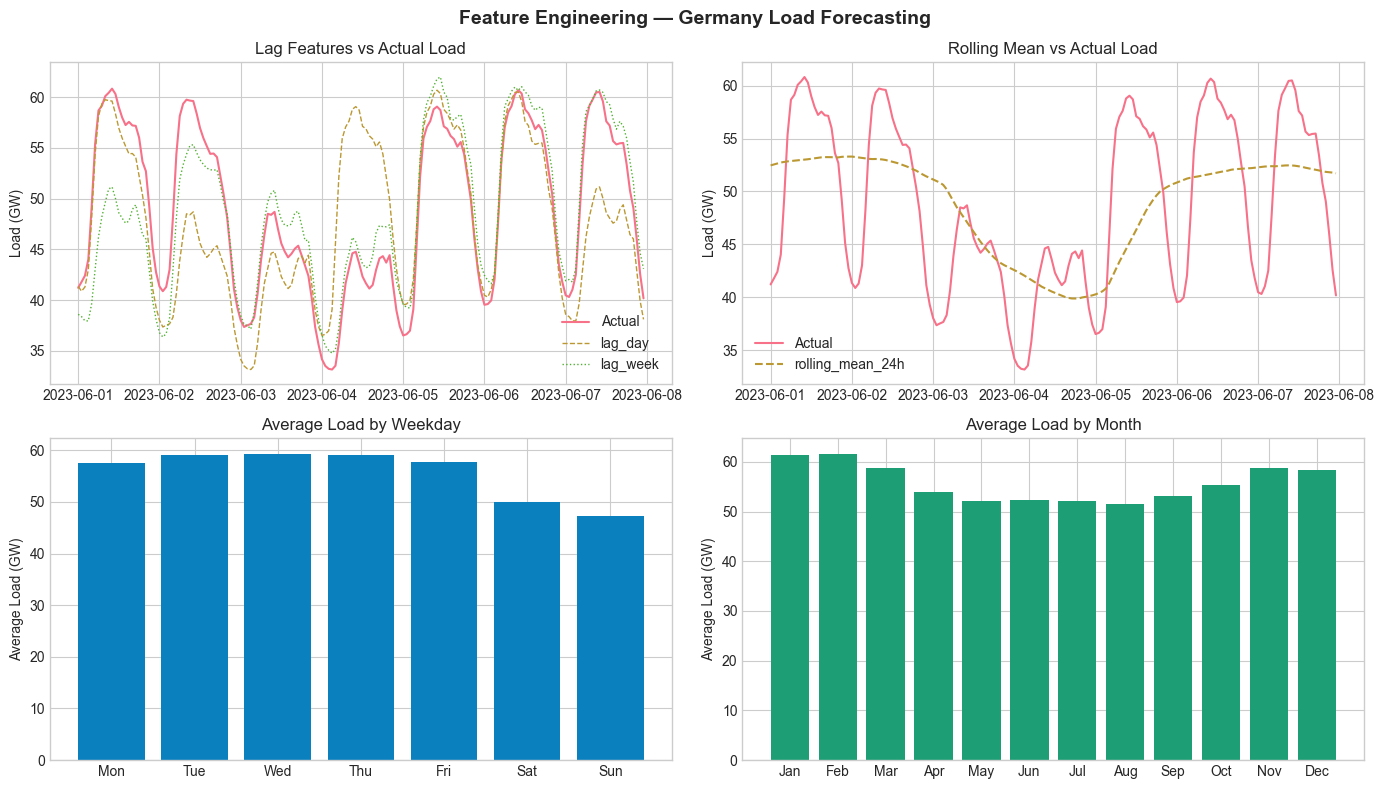

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")


fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 1 — Lag Features über Zeit (eine Woche)
axes[0,0].plot(df["Load_MW"].loc["2023-06-01":"2023-06-07"]/1000, label="Actual", linewidth=1.5)
axes[0,0].plot(df["lag_day"].loc["2023-06-01":"2023-06-07"]/1000, label="lag_day", linewidth=1, linestyle="--")
axes[0,0].plot(df["lag_week"].loc["2023-06-01":"2023-06-07"]/1000, label="lag_week", linewidth=1, linestyle=":")
axes[0,0].set_title("Lag Features vs Actual Load")
axes[0,0].set_ylabel("Load (GW)")
axes[0,0].legend()

# Plot 2 — Rolling Mean vs Actual
axes[0,1].plot(df["Load_MW"].loc["2023-06-01":"2023-06-07"]/1000, label="Actual", linewidth=1.5)
axes[0,1].plot(df["rolling_mean_24h"].loc["2023-06-01":"2023-06-07"]/1000, label="rolling_mean_24h", linewidth=1.5, linestyle="--")
axes[0,1].set_title("Rolling Mean vs Actual Load")
axes[0,1].set_ylabel("Load (GW)")
axes[0,1].legend()

# Plot 3 — Average load by weekday
weekday_avg = df.groupby("dayofweek")["Load_MW"].mean() / 1000
axes[1,0].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], weekday_avg, color="#0B80BE")
axes[1,0].set_title("Average Load by Weekday")
axes[1,0].set_ylabel("Average Load (GW)")

# Plot 4 — Average load by month
month_avg = df.groupby("month")["Load_MW"].mean() / 1000
axes[1,1].bar(range(1,13), month_avg, color="#1D9E75")
axes[1,1].set_title("Average Load by Month")
axes[1,1].set_ylabel("Average Load (GW)")
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

plt.suptitle("Feature Engineering — Germany Load Forecasting", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/05_features_overview.png", dpi=150, bbox_inches="tight")
plt.show()